In [ ]:
# MODELLO 5: recettori + osmosi con saturazione.
# Faccio il fit considerando anche i valori della membrana. Provo a eliminare k3. Non si adatta bene ai dati neanche così. Provo a usare il modello 1 considerando anche il washout dall'interno della cellula


import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
import matplotlib.pyplot as plt
import pandas as pd

# Impostazione dello stile grafico
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

In [2]:
# --- PARAMETRI FISICI ---
# Radionuclide di esempio: Lutezio-177 (177Lu)
T_half = 160.8  # Emivita fisica in ore (~6.7 giorni)
lmbda = np.log(2) / T_half  # Costante di decadimento fisico (h^-1)

# --- PARAMETRI ---
k0 = 1      # Costante dissociazione (h^-1) -> k-1
k1 = 0.1    # Costante di associazione (h^-1) -> cR*k1 negli appunti
k2 = 1      # Costante di internalizzazione tramite proteine (h^-1)
k3 = 0.0      # Costante di internalizzazione tramite osmosi (h^-1)

# --- PARAMETRI DELLA COLTURA ---
A0 = 1.0       # Attività iniziale iniettata nel terreno di coltura (kBq)
B_max = 0.01    # Attività massima sulla membrana (kBq)

In [3]:
def cellular_kinetic_system(t, y, lmbda, k0, k1, k2, k3, B_max):
    """
    Sistema ODE per la cinetica del radiofarmaco in vitro.
    y = [Am, Ab, Aint]
    """
    Am, Ab, Aint, Adec = y
    
    # Frazione di recettori di membrana ancora liberi (0 <= ratio <= 1)
    free_receptor_ratio = max(0.0, 1.0 - Ab / B_max)
    k1_eff = k1 * free_receptor_ratio

    # Equazioni differenziali del sistema
    dAm_dt = k0 * Ab - (lmbda + k3) * Am - k1_eff * Am
    dAb_dt = k1_eff * Am - (lmbda + k0 + k2) * Ab
    dAint_dt = -lmbda * Aint + k2 * Ab + k3 * Am
    dAdec_dt = lmbda * (Am + Ab + Aint)
    
    return [dAm_dt, dAb_dt, dAint_dt, dAdec_dt]

# Condizioni iniziali: tutta l'attivita e inizialmente nel terreno Am(0) = A0
y0 = [A0, 0.0, 0.0, 0.0]

# Intervallo temporale di simulazione (es. 72 ore)
t_span = (0, 144)
t_eval = np.linspace(t_span[0], t_span[1], 1000)

# Risoluzione del sistema ODE (metodo RK45)
sol = solve_ivp(
    cellular_kinetic_system, 
    t_span, 
    y0, 
    t_eval=t_eval, 
    args=(lmbda, k0, k1, k2, k3, B_max),
    method='RK45'
)

# Estrazione dei risultati
t = sol.t
Am, Ab, Aint, Adec = sol.y
A_cell_total = Ab + Aint  # Attività totale accumulata dalla cellula (membrana + internalizzata)
A_tot = Am + Ab + Aint + Adec

# Calcolo dell'Attività Cumulata A_tilde (integrale dell'attività nel tempo)
cumulated_activity_cell = np.trapezoid(A_cell_total, t)  # in kBq*h

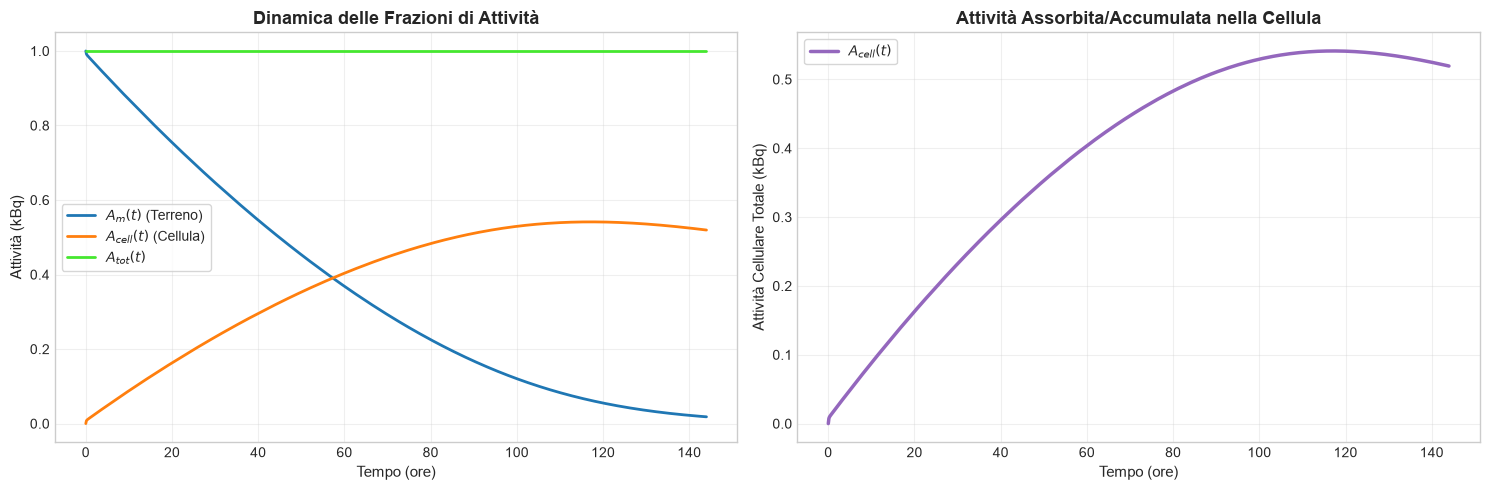

--------------------------------------------------
Attività Cumulata Cellulare Integrata (0-144h): 56.04 kBq·h
--------------------------------------------------


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Grafico 1: Cinetica nei tre compartimenti
axes[0].plot(t, Am, label='$A_m(t)$ (Terreno)', color='#1f77b4', linewidth=2)
axes[0].plot(t, A_cell_total, label='$A_{cell}(t)$ (Cellula)', color='#ff7f0e', linewidth=2)
axes[0].plot(t, A_tot, label='$A_{tot}(t)$', color="#45e72f", linewidth=2)
axes[0].set_xlabel('Tempo (ore)', fontsize=11)
axes[0].set_ylabel('Attività (kBq)', fontsize=11)
axes[0].set_title('Dinamica delle Frazioni di Attività', fontsize=13, fontweight='bold')
axes[0].legend(frameon=True)
axes[0].grid(True, alpha=0.3)

# Grafico 2: Attività Totale Cellulare e Saturazione
axes[1].plot(t, A_cell_total, label='$A_{cell}(t)$', color='#9467bd', linewidth=2.5)
axes[1].set_xlabel('Tempo (ore)', fontsize=11)
axes[1].set_ylabel('Attività Cellulare Totale (kBq)', fontsize=11)
axes[1].set_title('Attività Assorbita/Accumulata nella Cellula', fontsize=13, fontweight='bold')
axes[1].legend(frameon=True)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Stampa dell'attività cumulata
print(f"--------------------------------------------------")
print(f"Attività Cumulata Cellulare Integrata (0-{t_span[1]}h): {cumulated_activity_cell:.2f} kBq·h")
print(f"--------------------------------------------------")

In [5]:
A0_range = np.linspace(5, 500, 60)  # Variazione di A0 da 5 a 500 kBq

cumulated_A_list = []
max_A_cell_list = []

for A0_i in A0_range:
    # Risoluzione ODE per il generico A0_i
    y0_i = [A0_i, 0.0, 0.0, 0.0]
    sol_i = solve_ivp(
        cellular_kinetic_system, 
        t_span, 
        y0_i, 
        t_eval=t_eval, 
        args=(lmbda, k0, k1, k2, k3, B_max),
        method='RK45'
    )
    
    A_cell_i = sol_i.y[1] + sol_i.y[2]  # Ab + Aint
    
    # Salviamo il picco massimo e l'attività cumulata integrata (proporzionale alla dose)
    max_A_cell_list.append(np.max(A_cell_i))
    cumulated_A_list.append(np.trapezoid(A_cell_i, sol_i.t))

# --- VISUALIZZAZIONE GRAFICA ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Grafico 1: Curve temporali A_cell(t) per campioni significativi di A0
A0_samples = [10, 30, 80, 200, 500]
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(A0_samples)))

for A0_sample, color in zip(A0_samples, colors):
    sol_sample = solve_ivp(
        cellular_kinetic_system, 
        t_span, 
        [A0_sample, 0.0, 0.0, 0.0], 
        t_eval=t_eval, 
        args=(lmbda, k0, k1, k2, k3, B_max),
        method='RK45'
    )
    A_cell_sample = sol_sample.y[1] + sol_sample.y[2]
    axes[0].plot(sol_sample.t, A_cell_sample, label=f'$A_0$ = {A0_sample} kBq', color=color, linewidth=2)

axes[0].set_xlabel('Tempo (ore)', fontsize=11)
axes[0].set_ylabel('Attività Cellulare Totale $A_{cell}(t)$ (kBq)', fontsize=11)
axes[0].set_title('Evoluzione Temporale al Variare di $A_0$', fontsize=13, fontweight='bold')
axes[0].legend(frameon=True)
axes[0].grid(True, alpha=0.3)

# Grafico 2: Attività Cumulata vs A0 (Curva di Saturazione)
axes[1].plot(A0_range, cumulated_A_list, color='#2ca02c', linewidth=2.5)
axes[1].set_xlabel('Attività Iniziale Iniettata $A_0$ (kBq)', fontsize=11)
axes[1].set_ylabel('Attività Cumulata Cellulare $\\tilde{A}_{cell}$ (kBq·h)', fontsize=11)
axes[1].set_title('Attività Cumulata Integrata $\\tilde{A}_{cell}$ vs $A_0$', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Evidenziamo visivamente la deviazione dalla linearità
linear_trend = cumulated_A_list[0] / A0_range[0] * A0_range
axes[1].plot(A0_range, linear_trend, color='gray', linestyle=':', alpha=0.7, label='Comportamento Lineare Ideale (Senza Saturazione)')
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

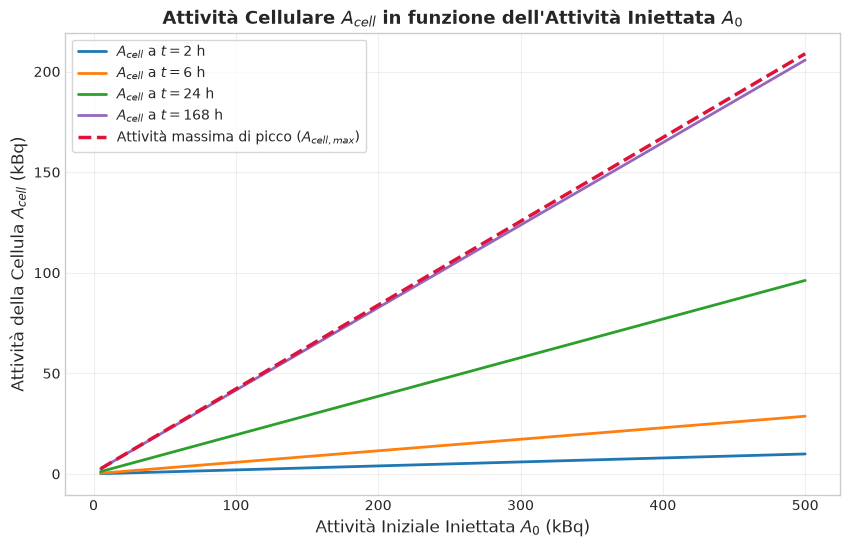

In [30]:
# --- PARAMETRIC SWEEP: A_cell vs A_0 ---
A0_range = np.linspace(5, 500, 100)  # Variazione continua dell'attività iniettata A0

# Tempi specifici a cui estrarre l'attività cellulare (in ore)
time_points = [2, 6, 24, 168]

# Dizionari e liste per raccogliere i dati
A_cell_at_times = {t_val: [] for t_val in time_points}
A_cell_max = []

for A0_i in A0_range:
    y0_i = [A0_i, 0.0, 0.0, 0.0]
    sol_i = solve_ivp(
        cellular_kinetic_system, 
        t_span, 
        y0_i, 
        t_eval=t_eval, 
        args=(lmbda, k0, k1, k2, k3, B_max),
        method='RK45'
    )
    
    A_cell_i = sol_i.y[1] + sol_i.y[2]  # A_cell(t) = Ab(t) + Aint(t)
    
    # Estraggo A_cell ai tempi prefissati
    for t_val in time_points:
        idx = np.argmin(np.abs(sol_i.t - t_val))  # Indice dell'istante t più vicino
        A_cell_at_times[t_val].append(A_cell_i[idx])
        
    # Estraggo il picco massimo assoluto di A_cell
    A_cell_max.append(np.max(A_cell_i))

# --- VISUALIZZAZIONE GRAFICA ---
plt.figure(figsize=(10, 6))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']

# Curve di A_cell(A0) ai vari tempi
for t_val, color in zip(time_points, colors):
    plt.plot(A0_range, A_cell_at_times[t_val], 
             label=f'$A_{{cell}}$ a $t = {t_val}$ h', 
             color=color, linewidth=2)

# Curva del picco massimo A_cell_max(A0)
plt.plot(A0_range, A_cell_max, 
         label='Attività massima di picco ($A_{cell, max}$)', 
         color='crimson', linestyle='--', linewidth=2.5)

# Formattazione grafico
plt.xlabel('Attività Iniziale Iniettata $A_0$ (kBq)', fontsize=12)
plt.ylabel('Attività della Cellula $A_{cell}$ (kBq)', fontsize=12)
plt.title('Attività Cellulare $A_{cell}$ in funzione dell\'Attività Iniettata $A_0$', fontsize=13, fontweight='bold')
plt.legend(frameon=True, fontsize=10)
plt.grid(True, alpha=0.3)

plt.show()

    RISULTATI FIT SIMULTANEO (TOTALE + MEMBRANA)  
k0_f (Dissociazione k_off) : 1.000000e-02 ± 6.591199e-07 h^-1
k1_f (Associazione k_on)   : 1.000031e-05 ± 4.745628e-06 h^-1
k2_f (Int. Proteica)       : 1.000100e-06 ± 2.061683e-07 h^-1
B_max_f (Saturazione Memb) : 1.000000e-02 ± 4.613021e-06 Bq/cellula
--------------------------------------------------
Punti Totali Fit           : 32 (16 tot + 16 mem)
Chi-quadro Totale (Chi2)   : 4666.1141
Gradi di libertà (dof)     : 28
Chi-quadro Ridotto         : 166.6469


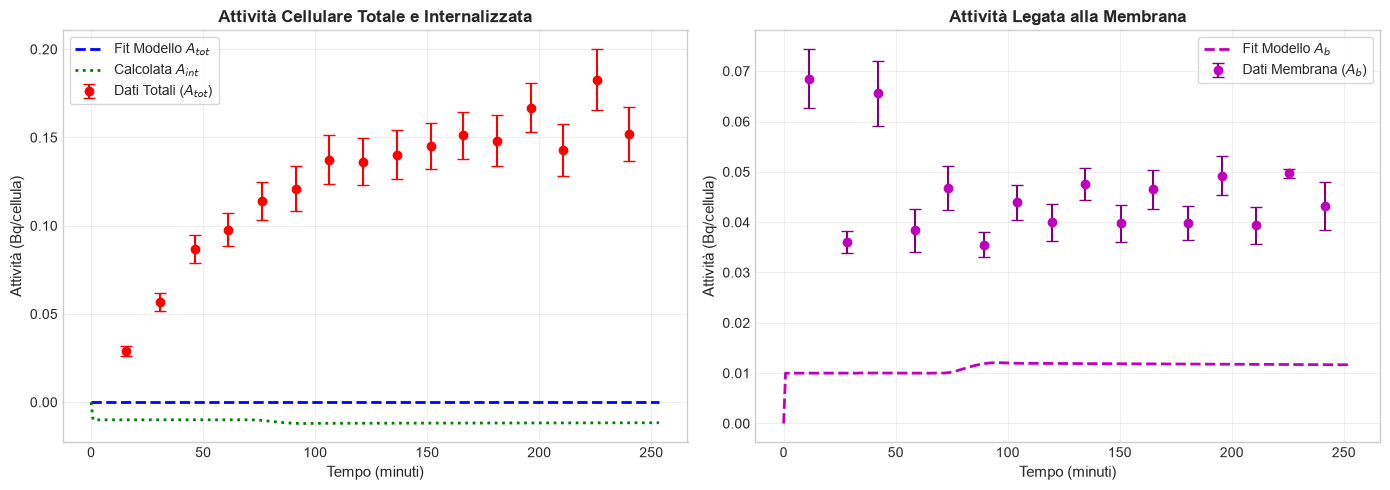

In [25]:
# =============================================================================
# 1. CARICAMENTO DEI 4 FILE CSV
# =============================================================================
# Set 1: Attività Totale (A_tot = A_b + A_int)
df_tot_data = pd.read_csv('dataset_prova2_valori.csv', header=None)
df_tot_err  = pd.read_csv('errori.csv', header=None)

t_min_tot = df_tot_data.iloc[:, 0].values
t_exp_tot = t_min_tot / 60.0  # In ore
y_tot_exp = df_tot_data.iloc[:, 1].values
err_tot   = np.maximum(np.abs((df_tot_err.iloc[:, 1].values - y_tot_exp)/2), 1e-8)

# Set 2: Attività di Membrana (A_b)
df_mem_data = pd.read_csv('dataset_prova2_membrana_valori.csv', header=None)
df_mem_err  = pd.read_csv('dataset_prova2_membrana_errori.csv', header=None)

t_min_mem = df_mem_data.iloc[:, 0].values
t_exp_mem = t_min_mem / 60.0  # In ore
y_mem_exp = df_mem_data.iloc[:, 1].values
err_mem   = np.maximum(np.abs((df_mem_err.iloc[:, 1].values - y_mem_exp)/2), 1e-8)

# Parametri radiometrici fisso
A0_val = 2500000.0  # Bq/mL
T_half = 160.8  # ore
lmbda = np.log(2) / T_half

# =============================================================================
# 2. MODELLO ODE E CALCOLO PREDIZIONI
# =============================================================================
def solve_ode_system(params, t_points, A0):
    """Risolve il sistema ODE e restituisce (A_membrana, A_totale)."""
    k0, k1, k2, B_max = params


    def ode_system(t, y):
        Am, Ab, Aint = y
        free_ratio = max(0.0, 1.0 - Ab / B_max) if B_max > 0 else 0.0
        k1_eff = k1 * free_ratio

        dAm_dt = k0 * Ab - k1_eff * Am
        dAb_dt = k1_eff * Am - (k0 + k2) * Ab
        dAint_dt = k2 * Ab
        return [dAm_dt, dAb_dt, dAint_dt]

    t_span = (0, float(np.max(t_points)))
    sol = solve_ivp(ode_system, t_span, [A0, 0.0, 0.0], t_eval=t_points, method='RK45')
    
    A_mem_pred = sol.y[1]                 # A_b
    A_tot_pred = sol.y[2]      # A_b + A_int
    return A_mem_pred, A_tot_pred

def simultaneous_residuals(params, t_tot, y_tot, e_tot, t_mem, y_mem, e_mem, A0):
    """Calcola un unico vettore di residui concatenando Totale e Membrana."""
    _, pred_tot = solve_ode_system(params, t_tot, A0)
    res_tot = (pred_tot - y_tot) / e_tot

    pred_mem, _ = solve_ode_system(params, t_mem, A0)
    res_mem = (pred_mem - y_mem) / e_mem

    return np.concatenate([res_tot, res_mem])

# =============================================================================
# 3. FIT SIMULTANEO
# =============================================================================
p0 = [0.01, 1e-5, 1e-6, 0.01]
lower_bounds = [1e-6, 1e-8, 1e-6, 1e-4]
upper_bounds = [5.0,  0.1,  5.0, 20.0]

res_fit = least_squares(
    simultaneous_residuals, 
    p0, 
    bounds=(lower_bounds, upper_bounds),
    args=(t_exp_tot, y_tot_exp, err_tot, t_exp_mem, y_mem_exp, err_mem, A0_val),
    method='trf'
)

# Estrazione parametri ed errori
k0_f, k1_f, k2_f, B_max_f = res_fit.x

N_tot_points = len(y_tot_exp) + len(y_mem_exp)
p_num = len(res_fit.x)
dof = N_tot_points - p_num

chi2 = np.sum(res_fit.fun**2)
chi2_red = chi2 / dof if dof > 0 else 1.0

J = res_fit.jac
try:
    cov = np.linalg.pinv(J.T @ J) * chi2_red
    param_errors = np.sqrt(np.diagonal(cov))
except Exception:
    param_errors = np.full(p_num, np.nan)

# =============================================================================
# 4. REPORT DEI RISULTATI
# =============================================================================
print("==================================================")
print("    RISULTATI FIT SIMULTANEO (TOTALE + MEMBRANA)  ")
print("==================================================")
print(f"k0_f (Dissociazione k_off) : {k0_f:.6e} ± {param_errors[0]:.6e} h^-1")
print(f"k1_f (Associazione k_on)   : {k1_f:.6e} ± {param_errors[1]:.6e} h^-1")
print(f"k2_f (Int. Proteica)       : {k2_f:.6e} ± {param_errors[2]:.6e} h^-1")
print(f"B_max_f (Saturazione Memb) : {B_max_f:.6e} ± {param_errors[3]:.6e} Bq/cellula")
print("--------------------------------------------------")
print(f"Punti Totali Fit           : {N_tot_points} ({len(y_tot_exp)} tot + {len(y_mem_exp)} mem)")
print(f"Chi-quadro Totale (Chi2)   : {chi2:.4f}")
print(f"Gradi di libertà (dof)     : {dof}")
print(f"Chi-quadro Ridotto         : {chi2_red:.4f}")
print("==================================================")

# =============================================================================
# 5. GRAFICO MULTI-PANNELLO
# =============================================================================
t_max_eval = max(np.max(t_exp_tot), np.max(t_exp_mem)) * 1.05
t_smooth_h = np.linspace(0, t_max_eval, 300)
pred_mem_smooth, pred_tot_smooth = solve_ode_system(res_fit.x, t_smooth_h, A0_val)
pred_int_smooth = pred_tot_smooth - pred_mem_smooth  # Frazione internalizzata teorica

t_smooth_min = t_smooth_h * 60.0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico 1: Attività Totale e Internalizzata
axes[0].errorbar(t_min_tot, y_tot_exp, yerr=err_tot, fmt='ro', ecolor='red', 
                 capsize=4, label='Dati Totali ($A_{tot}$)', zorder=5)
axes[0].plot(t_smooth_min, pred_tot_smooth, 'b--', linewidth=2, label='Fit Modello $A_{tot}$')
axes[0].plot(t_smooth_min, pred_int_smooth, 'g:', linewidth=2, label='Calcolata $A_{int}$')
axes[0].set_title('Attività Cellulare Totale e Internalizzata', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tempo (minuti)', fontsize=11)
axes[0].set_ylabel('Attività (Bq/cellula)', fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].legend(frameon=True)

# Grafico 2: Attività di Membrana
axes[1].errorbar(t_min_mem, y_mem_exp, yerr=err_mem, fmt='mo', ecolor='purple', 
                 capsize=4, label='Dati Membrana ($A_b$)', zorder=5)
axes[1].plot(t_smooth_min, pred_mem_smooth, 'm--', linewidth=2, label='Fit Modello $A_b$')
axes[1].set_title('Attività Legata alla Membrana', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tempo (minuti)', fontsize=11)
axes[1].set_ylabel('Attività (Bq/cellula)', fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()

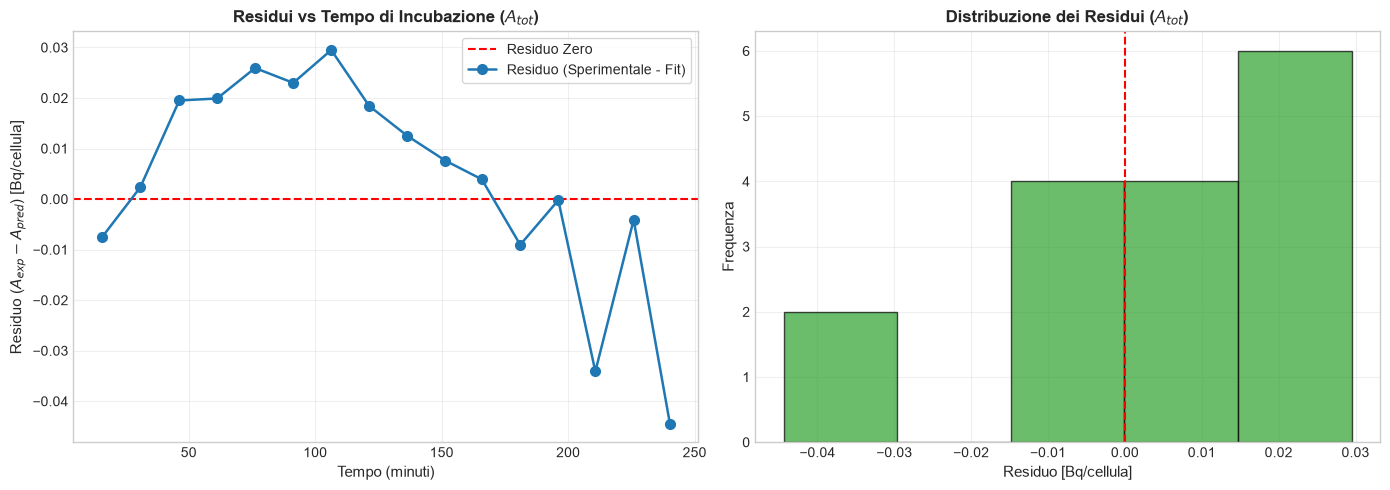

--------------------------------------------------
          STATISTICA DEI RESIDUI DEL FIT          
--------------------------------------------------
Media dei residui       : 3.940172e-03 Bq/cellula (ideale: ~0)
Deviazione Standard     : 2.010224e-02 Bq/cellula
Massimo errore assoluto : 4.441616e-02 Bq/cellula
--------------------------------------------------


In [7]:
# =============================================================================
# ANALISI DEI RESIDUI PER L'ATTIVITÀ TOTALE
# =============================================================================

# 1. Calcolo delle predizioni sui punti sperimentali e dei residui
_, preds_tot_exp = solve_ode_system(res_fit.x, t_exp_tot, A0_val)
residuals_val = y_tot_exp - preds_tot_exp

# 2. Creazione della figura con 2 grafici affiancati
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico A: Residui vs Tempo (in minuti)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5, label='Residuo Zero')
axes[0].plot(t_min_tot, residuals_val, 'o-', color='#1f77b4', markersize=7, linewidth=1.8, label='Residuo (Sperimentale - Fit)')
axes[0].set_title('Residui vs Tempo di Incubazione ($A_{tot}$)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tempo (minuti)', fontsize=11)
axes[0].set_ylabel('Residuo ($A_{exp} - A_{pred}$) [Bq/cellula]', fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].legend(frameon=True, fontsize=10)

# Grafico B: Istogramma della distribuzione dei residui
axes[1].hist(residuals_val, bins='auto', color='#2ca02c', edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Distribuzione dei Residui ($A_{tot}$)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Residuo [Bq/cellula]', fontsize=11)
axes[1].set_ylabel('Frequenza', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Metriche sintetiche della qualità del fit
print("--------------------------------------------------")
print("          STATISTICA DEI RESIDUI DEL FIT          ")
print("--------------------------------------------------")
print(f"Media dei residui       : {np.mean(residuals_val):.6e} Bq/cellula (ideale: ~0)")
print(f"Deviazione Standard     : {np.std(residuals_val):.6e} Bq/cellula")
print(f"Massimo errore assoluto : {np.max(np.abs(residuals_val)):.6e} Bq/cellula")
print("--------------------------------------------------")

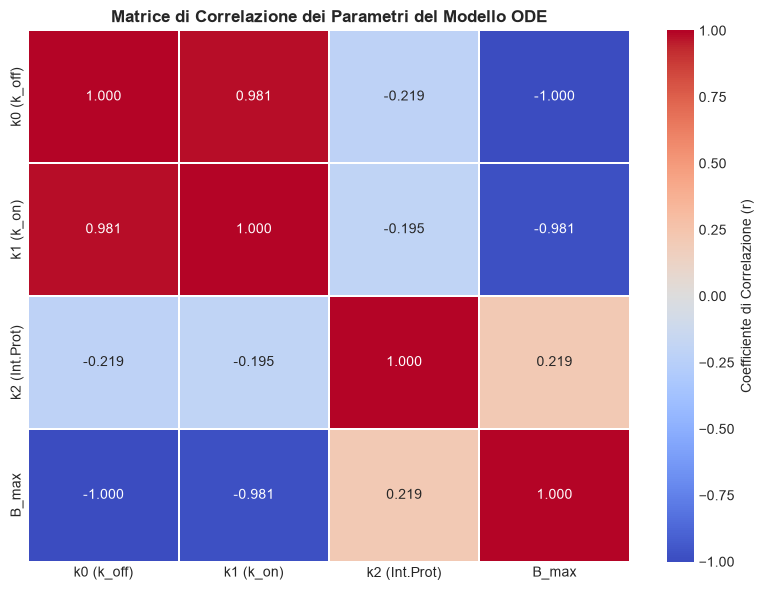

--------------------------------------------------
   ANALISI DELLE CORRELAZIONI ELEVATE (|r| > 0.85)  
--------------------------------------------------
⚠️  Alta correlazione: k0 (k_off) <---> k1 (k_on) (r = +0.981)
⚠️  Alta correlazione: k0 (k_off) <---> B_max (r = -1.000)
⚠️  Alta correlazione: k1 (k_on) <---> B_max (r = -0.981)

💡 Nota: Valori vicini a +1.0 o -1.0 indicano che i due parametri variano assieme
   e non possono essere stimati in modo indipendente senza fissarne uno.


In [8]:
# =============================================================================
# CELLA 2: MATRICE DI CORRELAZIONE DEI PARAMETRI
# =============================================================================
import pandas as pd
import seaborn as sns

# Nomi trasparenti dei parametri fittati
param_labels = ['k0 (k_off)', 'k1 (k_on)', 'k2 (Int.Prot)', 'B_max']

# 1. Calcolo della matrice di Covarianza e Correlazione
J = res_fit.jac
N_pts = len(A_cell_total)
p_num = len(res_fit.x)
dof_val = N_pts - p_num

ss_res_val = np.sum(res_fit.fun**2)
mse_val = ss_res_val / dof_val if dof_val > 0 else 1.0

cov_mat = np.linalg.pinv(J.T @ J) * mse_val
std_errs = np.sqrt(np.diagonal(cov_mat))

# Matrice di Correlazione R_ij = Cov_ij / (std_i * std_j)
outer_std = np.outer(std_errs, std_errs)
corr_mat = np.where(outer_std > 0, cov_mat / outer_std, 0.0)

# Creazione DataFrame pandas
df_corr = pd.DataFrame(corr_mat, index=param_labels, columns=param_labels)

# 2. Generazione Grafica della Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    df_corr, 
    annot=True, 
    fmt=".3f", 
    cmap='coolwarm', 
    vmin=-1.0, 
    vmax=1.0,
    linewidths=1.2, 
    cbar_kws={"label": "Coefficiente di Correlazione (r)"}
)
plt.title('Matrice di Correlazione dei Parametri del Modello ODE', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. Identificazione automatica dei parametri accoppiati/degeneri
print("--------------------------------------------------")
print("   ANALISI DELLE CORRELAZIONI ELEVATE (|r| > 0.85)  ")
print("--------------------------------------------------")
high_corr = False
for i in range(len(param_labels)):
    for j in range(i + 1, len(param_labels)):
        r_ij = corr_mat[i, j]
        if abs(r_ij) > 0.85:
            high_corr = True
            print(f"⚠️  Alta correlazione: {param_labels[i]} <---> {param_labels[j]} (r = {r_ij:+.3f})")

if not high_corr:
    print("✅ Nessuna correlazione critica (|r| > 0.85) rilevata tra i parametri.")
else:
    print("\n💡 Nota: Valori vicini a +1.0 o -1.0 indicano che i due parametri variano assieme")
    print("   e non possono essere stimati in modo indipendente senza fissarne uno.")